# Compile-time: `naive` LLM vs `mine` (ordered decomposition)

Run from `OD_vs_naive_comp_time/`. Aggregates **every run** under `results/run*/` (each run folder has `naive.csv` + `mine.csv`), computing mean±std per prop over the runs.

Three plots, all **linear** scale:
1. **naive vs mine** grouped bar (the comparison).
2. **naive** alone, per-prop mean ± std.
3. **mine** alone, per-prop mean ± std.

Status semantics: `ok` = built (a `sorry` in a *dependency* is fine — only the tested Main node must be sorry-free). `T.O.` = genuinely hit the wall cap → hatched bar at the cap (a censored lower bound). `fail` = a real Lean `error:` → annotated `FAIL`, **not** drawn as a timeout. The red cap line appears **only if something actually timed out**.

In [4]:
import re
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path('results')   # notebook lives in OD_vs_naive_comp_time/

def prop_label(target):        # 'Book1.Prop01.Main' -> '1.1'
    m = re.match(r'Book(\d+)\.Prop(\d+)', str(target))
    return f'{int(m.group(1))}.{int(m.group(2))}' if m else str(target)

rows = []
for method in ['naive', 'mine']:
    for f in sorted(RESULTS.glob(f'run*/{method}.csv')):
        d = pd.read_csv(f)
        d['prop'] = d['target'].map(prop_label)
        d['method'] = method
        d['run'] = f.parent.name
        rows.append(d[['prop', 'method', 'run', 'wall_s', 'status']])
assert rows, f'no run*/naive.csv or run*/mine.csv under {RESULTS.resolve()}'
long = pd.concat(rows, ignore_index=True)

_to = long.loc[long.status == 'T.O.', 'wall_s']
CAP = float(_to.max()) if len(_to) else None      # a real cap ONLY if something genuinely timed out; else there is no cap

def _key(p):
    a, b = p.split('.'); return (int(a), int(b))
PROPS = sorted(long.prop.unique(), key=_key)       # 1.1, 1.26, 1.43, 1.47, 3.33
print('runs   :', sorted(long.run.unique()))
print('methods:', sorted(long.method.unique()))
print('props  :', PROPS)
print('cap    :', CAP, '(None = nothing timed out)')
long

runs   : ['run1_20260717_224646', 'run2_20260717_230202', 'run3_20260717_231716', 'run4_20260717_233223', 'run5_20260717_234733']
methods: ['mine', 'naive']
props  : ['1.1', '1.26', '1.43', '1.47', '3.33']
cap    : None (None = nothing timed out)


,prop,method,run,wall_s,status
0,1.1,naive,run1_20260717_224646,4.89,ok
1,1.26,naive,run1_20260717_224646,98.48,ok
2,1.43,naive,run1_20260717_224646,101.63,ok
3,1.47,naive,run1_20260717_224646,350.15,ok
4,3.33,naive,run1_20260717_224646,123.69,ok
5,1.1,naive,run2_20260717_230202,5.74,ok
6,1.26,naive,run2_20260717_230202,100.17,ok
7,1.43,naive,run2_20260717_230202,102.06,ok
8,1.47,naive,run2_20260717_230202,347.52,ok
9,3.33,naive,run2_20260717_230202,123.34,ok


In [5]:
# mean/std over the 'ok' runs, per (method, prop); count T.O./fail
recs = []
for (method, prop), sub in long.groupby(['method', 'prop']):
    ok = sub.loc[sub.status == 'ok', 'wall_s']
    recs.append(dict(method=method, prop=prop,
                     mean=ok.mean() if len(ok) else np.nan,
                     std=ok.std(ddof=0) if len(ok) else 0.0,
                     n_ok=len(ok),
                     n_to=int((sub.status == 'T.O.').sum()),
                     n_fail=int((sub.status == 'fail').sum()),
                     n=len(sub)))
stats = pd.DataFrame(recs)

def series(method, col):
    s = stats[stats.method == method].set_index('prop')[col]
    return np.array([s.get(p, np.nan) for p in PROPS], float)

mean = {m: series(m, 'mean')   for m in ['naive', 'mine']}
std  = {m: series(m, 'std')    for m in ['naive', 'mine']}
nok  = {m: series(m, 'n_ok')   for m in ['naive', 'mine']}
nto  = {m: series(m, 'n_to')   for m in ['naive', 'mine']}
nfl  = {m: series(m, 'n_fail') for m in ['naive', 'mine']}

timedout = {m: np.nan_to_num(nto[m]) > 0 for m in ['naive', 'mine']}                 # hatch: genuine timeout only
failed   = {m: (np.nan_to_num(nok[m]) == 0) & (np.nan_to_num(nto[m]) == 0) & (np.nan_to_num(nfl[m]) > 0)
            for m in ['naive', 'mine']}                                             # annotate: real Lean error

def plotval(m):                     # bar height: mean if it ever compiled; else CAP if it timed out; else NaN (pure fail)
    v = mean[m].copy()
    if CAP is not None:
        v = np.where(np.isnan(v) & timedout[m], CAP, v)
    return v
plot = {m: plotval(m) for m in ['naive', 'mine']}
stats.sort_values(['method', 'prop']).reset_index(drop=True)

,method,prop,mean,std,n_ok,n_to,n_fail,n
0,mine,1.1,6.238,0.449239,5,0,0,5
1,mine,1.26,42.052,0.676562,5,0,0,5
2,mine,1.43,26.368,0.244655,5,0,0,5
3,mine,1.47,63.894,0.934336,5,0,0,5
4,mine,3.33,26.692,0.884000,5,0,0,5
5,naive,1.1,5.166,0.318283,5,0,0,5
6,naive,1.26,99.222,0.626687,5,0,0,5
7,naive,1.43,101.312,0.511562,5,0,0,5
8,naive,1.47,347.334,1.854213,5,0,0,5
9,naive,3.33,124.510,1.481513,5,0,0,5


## 1. naive vs mine (linear)

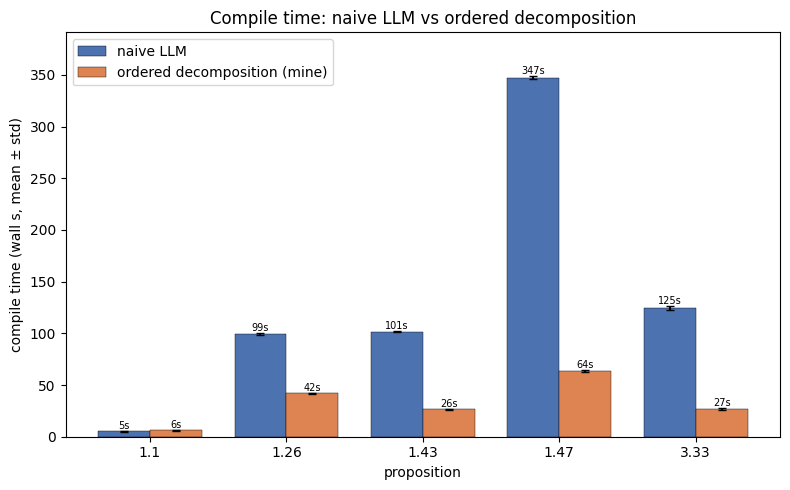

In [6]:
COL = {'naive': '#4C72B0', 'mine': '#DD8452'}
x = np.arange(len(PROPS)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))

def draw(off, m, label):
    err = np.where(timedout[m], 0, std[m])
    vals = np.where(np.isnan(plot[m]), 0, plot[m])
    bars = ax.bar(x + off, vals, width=w, color=COL[m], label=label,
                  yerr=err, capsize=3, edgecolor='black', linewidth=0.3)
    for b, to, fl, e in zip(bars, timedout[m], failed[m], err):
        if to:
            b.set_hatch('///')
        if fl:
            ax.annotate('FAIL', (b.get_x() + b.get_width()/2, 0), ha='center', va='bottom',
                        color='red', fontsize=8, rotation=90)
        else:
            h = b.get_height()
            if np.isfinite(h) and h > 0:
                ax.annotate(f'{h:.0f}s', (b.get_x() + b.get_width()/2, h + e), ha='center',
                            va='bottom', fontsize=7)

draw(-w/2, 'naive', 'naive LLM')
draw(w/2, 'mine', 'ordered decomposition (mine)')
if CAP is not None:
    ax.axhline(CAP, color='red', ls=':', lw=1, label=f'cap {CAP:.0f}s')
ax.set_xticks(x); ax.set_xticklabels(PROPS)
ax.set_yscale('linear')
ax.margins(y=0.12)   # headroom so the top labels aren't clipped
ax.set_xlabel('proposition'); ax.set_ylabel('compile time (wall s, mean ± std)')
title = 'Compile time: naive LLM vs ordered decomposition'
if any(timedout[m].any() for m in COL):
    title += '   (hatched = never finished within cap)'
ax.set_title(title)
ax.legend()
plt.tight_layout(); plt.show()